# 13. Train And Evaluate Models

Final training and evaluation notebook for the project

Outcome definitions are kept explicit throughout:

- **Broad outcome mode**: all events with a valid follow-up HbA1c label
- **Unchanged-therapy outcome mode**: only events meeting the unchanged-therapy approximation

Model implemented:

1. **K-means** for unsupervised structure discovery on static features
2. **Elastic Net** baseline
3. **HistGradientBoostingRegressor** baseline
4. **CNN** on static baseline features
5. **GRU** on longitudinal event-aligned sequences

All tasks are separated and labeled in separate sections

## 1. Imports And Configuration

In [1]:
from __future__ import annotations

import json

import gc
import os
import math
import random
from contextlib import contextmanager
from collections import defaultdict
from pathlib import Path

import lightning.pytorch as pl
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset

PROJECT_ROOT = Path.cwd()
FULL_PROJECT_DIR = PROJECT_ROOT / 'data' / 'full_project'
MODELING_DIR = FULL_PROJECT_DIR / 'modeling'
OUTCOMES_DIR = FULL_PROJECT_DIR / 'outcomes'
TRAINING_DIR = FULL_PROJECT_DIR / 'training'
TRAINING_DIR.mkdir(parents=True, exist_ok=True)

STATIC_EVENT_TABLE_PATH = MODELING_DIR / 'static_event_modeling_table.csv'
PATIENT_SPLITS_PATH = MODELING_DIR / 'patient_splits.csv'
EVENT_SPLITS_PATH = MODELING_DIR / 'event_splits.csv'
MODELING_MANIFEST_PATH = MODELING_DIR / 'modeling_manifest.json'
BROAD_OUTCOME_PATH = OUTCOMES_DIR / 'full_project_outcome_hba1c.csv'
UNCHANGED_OUTCOME_PATH = OUTCOMES_DIR / 'full_project_outcome_hba1c_eligible.csv'

UNSUPERVISED_RESULTS_PATH = TRAINING_DIR / 'unsupervised_kmeans_summary.csv'
STATIC_TUNING_PATH = TRAINING_DIR / 'optuna_static_trials.csv'
STATIC_PARAM_PATH = TRAINING_DIR / 'optuna_static_best_params.json'
STATIC_TEST_RESULTS_PATH = TRAINING_DIR / 'static_test_results.csv'
DEEP_TUNING_PATH = TRAINING_DIR / 'optuna_deep_trials.csv'
DEEP_PARAM_PATH = TRAINING_DIR / 'optuna_deep_best_params.json'
DEEP_TEST_RESULTS_PATH = TRAINING_DIR / 'deep_test_results.csv'
DEEP_OPTUNA_STORAGE_PATH = TRAINING_DIR / 'optuna_deep_studies.sqlite3'
SEQUENCE_EXAMPLE_CACHE_DIR = TRAINING_DIR / 'sequence_example_cache'
SEQUENCE_EXAMPLE_CACHE_DIR.mkdir(parents=True, exist_ok=True)
TRAINING_MANIFEST_PATH = TRAINING_DIR / 'training_manifest.json'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

OUTCOME_MODES = ['broad', 'unchanged_therapy']
PRIMARY_OUTCOME_MODE = 'broad'
EXPLORATION_OUTCOME_MODE = PRIMARY_OUTCOME_MODE

SMOKE_TEST_MODE = False
SMOKE_TEST_PATIENTS_PER_SPLIT = {
    'train': 2000,
    'validation': 500,
    'test': 500,
}

RUN_UNSUPERVISED = True
RUN_OPTUNA_STATIC = True
RUN_STATIC_FINAL = True
RUN_SEQUENCE_CACHE_BUILD = True
RUN_OPTUNA_DEEP = True
RUN_DEEP_FINAL = True

N_TRIALS_STATIC = 2 if SMOKE_TEST_MODE else 20
N_TRIALS_DEEP = 1 if SMOKE_TEST_MODE else 10
MAX_SEQ_LEN = 64 if SMOKE_TEST_MODE else 128
SEQUENCE_VALUE_FILL = 0.0
SEQUENCE_CHUNKSIZE = 250_000
SEQUENCE_DOMAINS_FOR_GRU = [
    'sequence_hba1c',
    'sequence_core_labs',
    'sequence_glucose_meds',
    'sequence_body_size',
]

CNN_MAX_EPOCHS = 2 if SMOKE_TEST_MODE else 20
GRU_MAX_EPOCHS = 2 if SMOKE_TEST_MODE else 6
BATCH_SIZE = 128 if SMOKE_TEST_MODE else 256
LR = 1e-3
NUM_WORKERS = 0 if SMOKE_TEST_MODE else min(4, os.cpu_count() or 1)
PIN_MEMORY = torch.cuda.is_available()
EARLY_STOPPING_PATIENCE = 2 if SMOKE_TEST_MODE else 2
GRU_BIDIRECTIONAL = False
DEEP_STUDY_VERSION = f"seq{MAX_SEQ_LEN}_gru{'bi' if GRU_BIDIRECTIONAL else 'uni'}_ep{GRU_MAX_EPOCHS}"

sns.set_theme(style='whitegrid')

print('torch version:', torch.__version__)
print('lightning module:', pl.__name__)
print('optuna version:', optuna.__version__)
print('Smoke test mode:', SMOKE_TEST_MODE)
if SMOKE_TEST_MODE:
    print('Smoke test patients per split:', SMOKE_TEST_PATIENTS_PER_SPLIT)
print('CUDA available:', torch.cuda.is_available())
print('Notebook 13 environment loaded successfully.')


/uufs/chpc.utah.edu/common/home/u1523752/.conda/envs/andre_trinetx/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch version: 2.11.0+cu130
lightning module: lightning.pytorch
optuna version: 4.8.0
Smoke test mode: False
CUDA available: False
Notebook 13 environment loaded successfully.


  raw_cnt = _raw_device_count_nvml()


## 2. Load Modeling Artifacts

In [2]:
assert STATIC_EVENT_TABLE_PATH.exists(), STATIC_EVENT_TABLE_PATH
assert PATIENT_SPLITS_PATH.exists(), PATIENT_SPLITS_PATH
assert EVENT_SPLITS_PATH.exists(), EVENT_SPLITS_PATH
assert MODELING_MANIFEST_PATH.exists(), MODELING_MANIFEST_PATH
assert BROAD_OUTCOME_PATH.exists(), BROAD_OUTCOME_PATH
assert UNCHANGED_OUTCOME_PATH.exists(), UNCHANGED_OUTCOME_PATH

with open(MODELING_MANIFEST_PATH) as f:
    modeling_manifest = json.load(f)

static_event_modeling_table = pd.read_csv(
    STATIC_EVENT_TABLE_PATH,
    parse_dates=['index_date', 'first_t2d_date', 'baseline_hba1c_date'],
)
patient_splits = pd.read_csv(PATIENT_SPLITS_PATH)
event_splits = pd.read_csv(EVENT_SPLITS_PATH)
aligned_sequence_paths = {k: Path(v) for k, v in modeling_manifest['aligned_sequence_paths'].items()}

print('Static rows:', len(static_event_modeling_table))
print('Static patients:', static_event_modeling_table['patient_id'].nunique())
print('Patient splits:', patient_splits['split'].value_counts().to_dict())
print('Event splits:', event_splits['split'].value_counts().to_dict())
display(static_event_modeling_table.head(3))

Static rows: 120224
Static patients: 94651
Patient splits: {'train': 66528, 'test': 14151, 'validation': 13972}
Event splits: {'train': 84621, 'test': 17901, 'validation': 17702}


,patient_id,drug_class,index_date,event_id,age_at_index,sex,first_t2d_date,baseline_hba1c_date,code_system,code,...,prior_sulfonylurea_2y,prior_tzd_2y,baseline_hba1c_missing,egfr_missing,hdl_missing,total_cholesterol_missing,alt_missing,bmi_final_missing,weight_lb_missing,height_in_missing
0,#A##B,GLP1,2019-07-03,event_0000001,74.0,M,2019-03-28,2019-06-19,LOINC,17856-6,...,0,0,0,0,0,0,0,1,1,0
1,#A##B,SGLT2,2023-12-14,event_0000002,78.0,M,2019-03-28,2023-12-04,LOINC,17856-6,...,0,0,0,0,0,0,0,1,1,0
2,#A#0B,GLP1,2023-08-16,event_0000003,53.0,F,2022-03-18,2023-08-12,LOINC,4548-4,...,1,0,0,0,0,0,0,1,1,0


## 3. Define Outcome Modes Clearly

In [3]:
OUTCOME_MODE_CONFIG = {
    'broad': {
        'label': 'Broad outcome file',
        'path': BROAD_OUTCOME_PATH,
        'description': 'All events with a valid follow-up HbA1c label.',
    },
    'unchanged_therapy': {
        'label': 'Unchanged-therapy eligible outcome file',
        'path': UNCHANGED_OUTCOME_PATH,
        'description': 'Only events meeting the unchanged-therapy approximation.',
    },
}

def load_outcome_mode(mode: str) -> pd.DataFrame:
    cfg = OUTCOME_MODE_CONFIG[mode]
    df = pd.read_csv(cfg['path'], parse_dates=['index_date'])
    keep_cols = ['event_id', 'patient_id', 'drug_class', 'index_date', 'outcome_hba1c']
    if 'unchanged_therapy_approx' in df.columns:
        keep_cols.append('unchanged_therapy_approx')
    df = df[keep_cols].copy()
    df['patient_id'] = df['patient_id'].astype('string')
    df['outcome_mode'] = mode
    return df

outcome_mode_summary = pd.DataFrame([
    {
        'outcome_mode': mode,
        'label': OUTCOME_MODE_CONFIG[mode]['label'],
        'rows': len(load_outcome_mode(mode)),
        'patients': load_outcome_mode(mode)['patient_id'].nunique(),
        'classes': load_outcome_mode(mode)['drug_class'].nunique(),
        'description': OUTCOME_MODE_CONFIG[mode]['description'],
    }
    for mode in OUTCOME_MODES
])
display(outcome_mode_summary)

,outcome_mode,label,rows,patients,classes,description
0,broad,Broad outcome file,97673,77016,3,All events with a valid follow-up HbA1c label.
1,unchanged_therapy,Unchanged-therapy eligible outcome file,51058,46435,3,Only events meeting the unchanged-therapy appr...


## 4. Build Mode-Specific Training Tables

In [4]:
STATIC_NUMERIC_FEATURES = [
    'age_at_index', 'baseline_hba1c', 't2d_duration_days', 'egfr', 'hdl',
    'total_cholesterol', 'alt', 'bmi_final', 'weight_lb', 'height_in',
    'glucose_med_record_rows_2y', 'first_glucose_med_days_before_index',
    'last_glucose_med_days_before_index', 'prior_metformin_2y',
    'prior_insulin_2y', 'prior_glp1_2y', 'prior_sglt2_2y', 'prior_dpp4_2y',
    'prior_sulfonylurea_2y', 'prior_tzd_2y',
]
STATIC_CATEGORICAL_FEATURES = ['sex', 'drug_class']
STATIC_NUMERIC_FEATURES = [c for c in STATIC_NUMERIC_FEATURES if c in static_event_modeling_table.columns]
STATIC_CATEGORICAL_FEATURES = [c for c in STATIC_CATEGORICAL_FEATURES if c in static_event_modeling_table.columns]

def sample_split_patients(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    split_df = df[df['split'] == split_name].copy()
    if not SMOKE_TEST_MODE:
        return split_df
    limit = SMOKE_TEST_PATIENTS_PER_SPLIT.get(split_name)
    unique_patients = split_df['patient_id'].dropna().astype('string').unique().tolist()
    if limit is None or len(unique_patients) <= limit:
        return split_df
    sampled_patients = pd.Series(unique_patients).sample(n=limit, random_state=SEED).astype('string')
    return split_df[split_df['patient_id'].astype('string').isin(set(sampled_patients.tolist()))].copy()


def apply_smoke_test_sampling(df: pd.DataFrame) -> pd.DataFrame:
    if not SMOKE_TEST_MODE:
        return df
    sampled_parts = [sample_split_patients(df, split_name) for split_name in ['train', 'validation', 'test']]
    sampled_df = pd.concat(sampled_parts, ignore_index=True)
    sampled_df = sampled_df.sort_values(['split', 'patient_id', 'event_id']).reset_index(drop=True)
    return sampled_df

def build_mode_static_table(mode: str) -> pd.DataFrame:
    outcome_df = load_outcome_mode(mode)
    merged = static_event_modeling_table.merge(
        outcome_df[['event_id', 'outcome_hba1c', 'outcome_mode']],
        on='event_id',
        how='inner',
    )
    merged['patient_id'] = merged['patient_id'].astype('string')
    merged = merged.merge(event_splits, on=['event_id', 'patient_id'], how='left')
    merged = apply_smoke_test_sampling(merged)
    return merged

mode_static_tables = {mode: build_mode_static_table(mode) for mode in OUTCOME_MODES}

mode_static_summary = pd.DataFrame([
    {
        'outcome_mode': mode,
        'rows': len(df),
        'patients': df['patient_id'].nunique(),
        'train_rows': int((df['split'] == 'train').sum()),
        'validation_rows': int((df['split'] == 'validation').sum()),
        'test_rows': int((df['split'] == 'test').sum()),
        'smoke_test_mode': SMOKE_TEST_MODE,
    }
    for mode, df in mode_static_tables.items()
])
display(mode_static_summary)


,outcome_mode,rows,patients,train_rows,validation_rows,test_rows,smoke_test_mode
0,broad,97673,77016,68757,14376,14540,False
1,unchanged_therapy,51058,46435,35799,7627,7632,False


## 5. Pre-QC Training-Set Exploration And Visual Checks

Exploration outcome mode: broad
Training rows: 68757
Training patients: 54139


,outcome_mode,train_rows,train_patients,mean_outcome_hba1c,mean_baseline_hba1c,bmi_final_nonmissing_pct
0,broad,68757,54139,7.801,8.68,74.39
1,unchanged_therapy,35799,32576,7.680,8.64,72.76


,count,mean,std,min,25%,50%,75%,max
age_at_index,68757.0,59.201958,11.633624,18.00,52.0000,60.0000,68.0000,79.000000
baseline_hba1c,68757.0,8.679720,1.270216,7.00,7.7000,8.4000,9.4000,12.200000
t2d_duration_days,68757.0,1747.274328,1594.040191,0.00,563.0000,1370.0000,2441.0000,23205.000000
egfr,66088.0,95.909553,243.555278,0.00,70.0000,89.0000,103.0000,10220.000000
hdl,61512.0,37.571837,19.401559,-1.67,31.0000,40.0000,49.0000,192.000000
total_cholesterol,61732.0,166.196454,45.692272,0.00,136.0000,161.0000,191.0000,832.000000
alt,42941.0,30.312682,22.205078,0.00,17.0000,24.0000,36.0000,460.000000
bmi_final,51149.0,33.528152,6.778012,2.40,28.4868,32.8600,38.0121,69.339084
weight_lb,50331.0,209.155720,51.455326,80.00,172.0000,205.4710,242.0000,450.000000
height_in,57948.0,66.153244,4.092312,56.00,63.0000,65.9999,69.0000,81.000000


,feature,missing_rows,missing_pct
6,alt,25816,37.55
8,weight_lb,18426,26.80
7,bmi_final,17608,25.61
9,height_in,10809,15.72
4,hdl,7245,10.54
5,total_cholesterol,7025,10.22
11,first_glucose_med_days_before_index,3462,5.04
10,glucose_med_record_rows_2y,3462,5.04
12,last_glucose_med_days_before_index,3462,5.04
3,egfr,2669,3.88


,baseline_hba1c,outcome_hba1c,age_at_index,t2d_duration_days,egfr,hdl,total_cholesterol,alt,bmi_final
baseline_hba1c,1.000,0.324,-0.158,-0.013,0.011,-0.057,0.155,0.048,0.023
outcome_hba1c,0.324,1.000,-0.062,0.026,-0.002,-0.018,0.073,-0.045,-0.034
age_at_index,-0.158,-0.062,1.000,0.205,-0.056,0.093,-0.185,-0.225,-0.252
t2d_duration_days,-0.013,0.026,0.205,1.000,-0.046,-0.128,-0.092,-0.098,-0.077
egfr,0.011,-0.002,-0.056,-0.046,1.000,0.011,0.019,0.012,-0.000
hdl,-0.057,-0.018,0.093,-0.128,0.011,1.000,0.122,-0.057,-0.125
total_cholesterol,0.155,0.073,-0.185,-0.092,0.019,0.122,1.000,0.063,0.026
alt,0.048,-0.045,-0.225,-0.098,0.012,-0.057,0.063,1.000,0.089
bmi_final,0.023,-0.034,-0.252,-0.077,-0.000,-0.125,0.026,0.089,1.000


,train_rows
drug_class,
GLP1,26686
SGLT2,25825
DPP4,16246


/scratch/local/u1523752/18519853/ipykernel_1882865/1258396743.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=explore_train_df, x='drug_class', order=explore_train_df['drug_class'].value_counts().index, ax=axes[2], palette='deep')


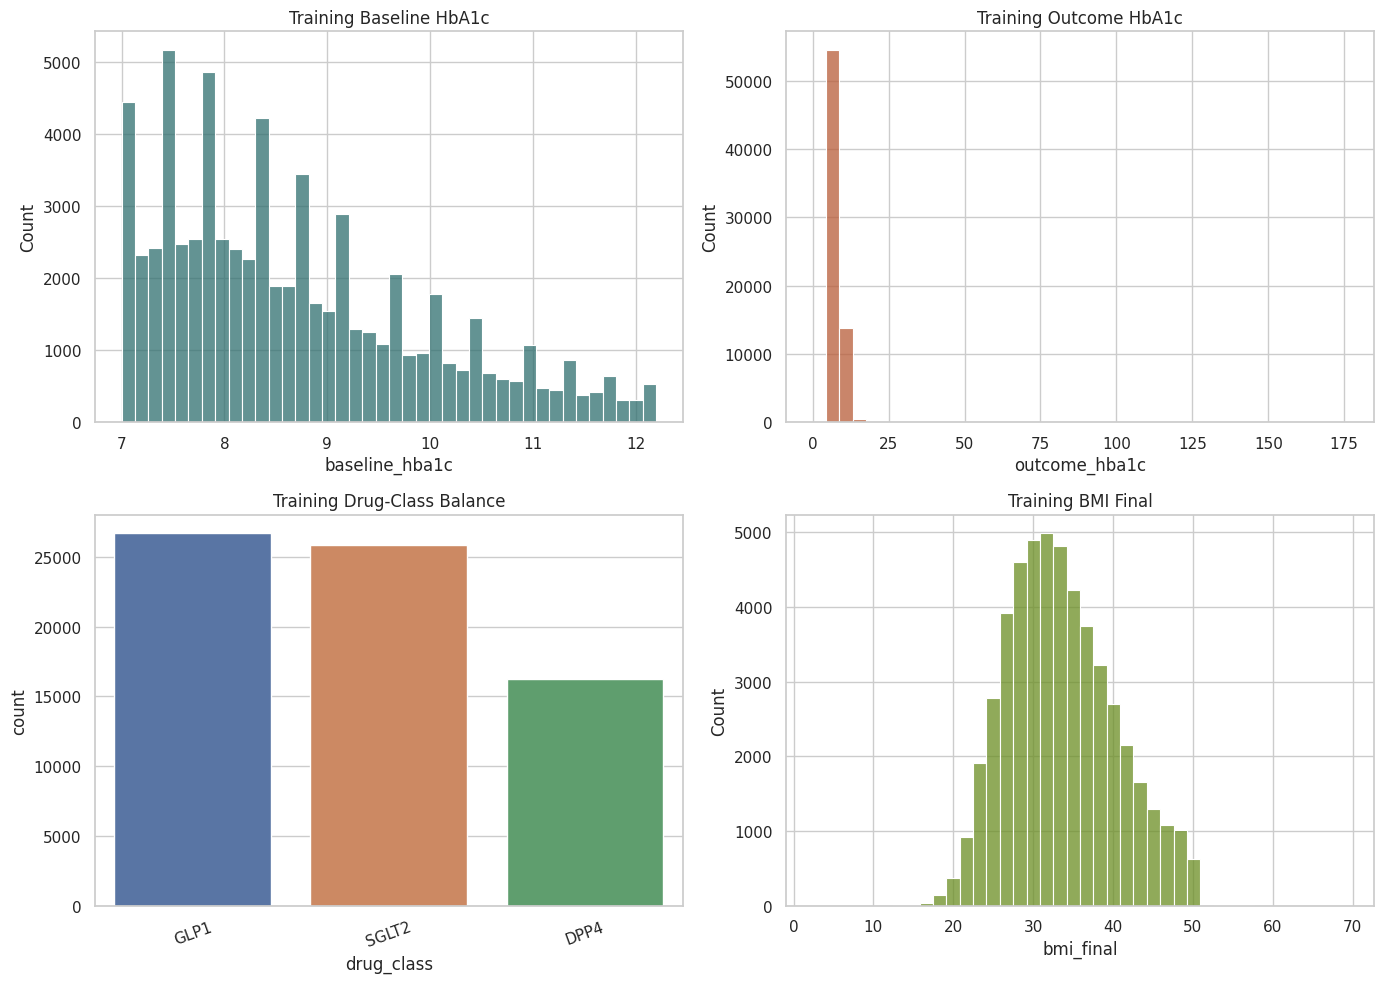

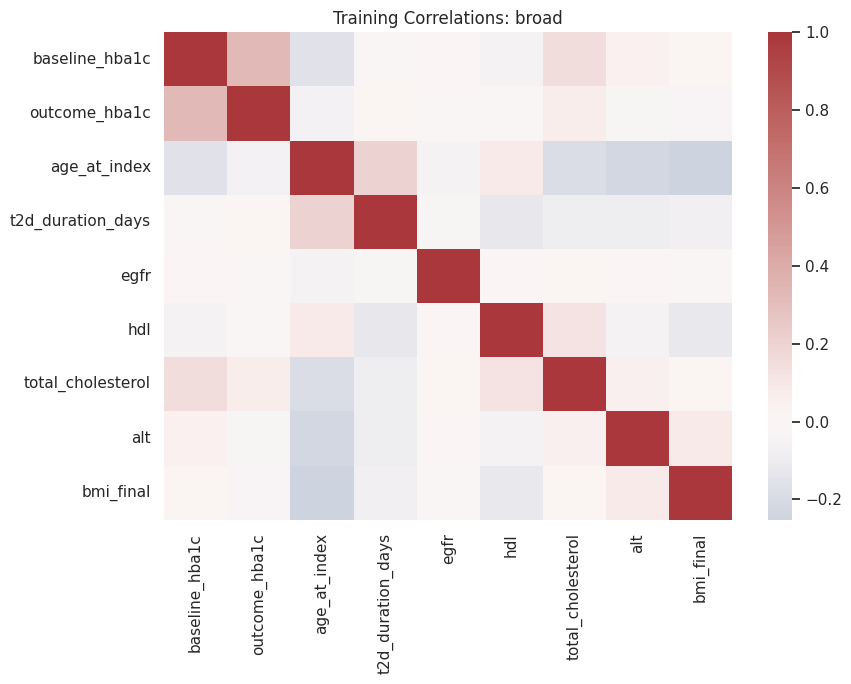

In [5]:
explore_df = mode_static_tables[EXPLORATION_OUTCOME_MODE].copy()
explore_train_df = explore_df[explore_df['split'] == 'train'].copy()

print('Exploration outcome mode:', EXPLORATION_OUTCOME_MODE)
print('Training rows:', len(explore_train_df))
print('Training patients:', explore_train_df['patient_id'].nunique())

summary_rows = []
for mode, df in mode_static_tables.items():
    train_df = df[df['split'] == 'train'].copy()
    summary_rows.append({
        'outcome_mode': mode,
        'train_rows': len(train_df),
        'train_patients': train_df['patient_id'].nunique(),
        'mean_outcome_hba1c': round(train_df['outcome_hba1c'].mean(), 3),
        'mean_baseline_hba1c': round(train_df['baseline_hba1c'].mean(), 3),
        'bmi_final_nonmissing_pct': round(train_df['bmi_final'].notna().mean() * 100, 2) if 'bmi_final' in train_df.columns else np.nan,
    })
display(pd.DataFrame(summary_rows))

numeric_explore_features = [
    'age_at_index', 'baseline_hba1c', 't2d_duration_days', 'egfr', 'hdl',
    'total_cholesterol', 'alt', 'bmi_final', 'weight_lb', 'height_in',
    'glucose_med_record_rows_2y', 'first_glucose_med_days_before_index',
    'last_glucose_med_days_before_index', 'outcome_hba1c',
]
numeric_explore_features = [c for c in numeric_explore_features if c in explore_train_df.columns]

display(explore_train_df[numeric_explore_features].describe().T)

missingness_table = pd.DataFrame({
    'feature': numeric_explore_features,
    'missing_rows': [int(explore_train_df[c].isna().sum()) for c in numeric_explore_features],
    'missing_pct': [round(explore_train_df[c].isna().mean() * 100, 2) for c in numeric_explore_features],
}).sort_values(['missing_pct', 'feature'], ascending=[False, True])
display(missingness_table)

corr_features = [c for c in ['baseline_hba1c', 'outcome_hba1c', 'age_at_index', 't2d_duration_days', 'egfr', 'hdl', 'total_cholesterol', 'alt', 'bmi_final'] if c in explore_train_df.columns]
corr = explore_train_df[corr_features].corr(numeric_only=True)
display(corr.round(3))

display(explore_train_df['drug_class'].value_counts(dropna=False).rename_axis('drug_class').to_frame('train_rows'))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
sns.histplot(explore_train_df['baseline_hba1c'].dropna(), bins=40, ax=axes[0], color='#2f6f6f')
axes[0].set_title('Training Baseline HbA1c')
sns.histplot(explore_train_df['outcome_hba1c'].dropna(), bins=40, ax=axes[1], color='#b85c38')
axes[1].set_title('Training Outcome HbA1c')
sns.countplot(data=explore_train_df, x='drug_class', order=explore_train_df['drug_class'].value_counts().index, ax=axes[2], palette='deep')
axes[2].set_title('Training Drug-Class Balance')
axes[2].tick_params(axis='x', rotation=20)
if 'bmi_final' in explore_train_df.columns:
    sns.histplot(explore_train_df['bmi_final'].dropna(), bins=40, ax=axes[3], color='#6b8e23')
    axes[3].set_title('Training BMI Final')
else:
    axes[3].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap='vlag', center=0, annot=False)
plt.title(f'Training Correlations: {EXPLORATION_OUTCOME_MODE}')
plt.tight_layout()
plt.show()

## 6. QC, Clipping, And Shared Helpers

This section converts clearly impossible values to missing, removes impossible outcome labels, and applies training-derived clipping bounds to selected continuous predictors before model fitting. That keeps preprocessing explicit and avoids leakage.

When `SMOKE_TEST_MODE = True`, the QC and all downstream model sections run on sampled patients within each split so we can validate logic quickly before full-scale training.


In [6]:
HARD_QC_RULES = {
    'age_at_index': (18, 90),
    'baseline_hba1c': (4.0, 20.0),
    'outcome_hba1c': (4.0, 20.0),
    't2d_duration_days': (0, 36525),
    'egfr': (1.0, 200.0),
    'hdl': (1.0, 150.0),
    'total_cholesterol': (50.0, 500.0),
    'alt': (1.0, 1000.0),
    'bmi_final': (10.0, 80.0),
    'weight_lb': (50.0, 700.0),
    'height_in': (48.0, 90.0),
    'glucose_med_record_rows_2y': (0.0, None),
    'first_glucose_med_days_before_index': (0.0, 730.0),
    'last_glucose_med_days_before_index': (0.0, 730.0),
}

TRAINING_CLIP_FEATURES = [
    'baseline_hba1c',
    't2d_duration_days',
    'egfr',
    'hdl',
    'total_cholesterol',
    'alt',
    'bmi_final',
    'weight_lb',
    'height_in',
    'glucose_med_record_rows_2y',
    'first_glucose_med_days_before_index',
    'last_glucose_med_days_before_index',
]


def regression_metrics(y_true, y_pred) -> dict:
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(rmse),
        'r2': float(r2_score(y_true, y_pred)),
    }


def apply_hard_qc_ranges(df: pd.DataFrame):
    df = df.copy()
    qc_rows = []
    for col, (lower, upper) in HARD_QC_RULES.items():
        if col not in df.columns:
            continue
        series = pd.to_numeric(df[col], errors='coerce')
        invalid = series.notna()
        if lower is not None:
            invalid &= series < lower
        else:
            invalid &= False
        if upper is not None:
            invalid |= (series.notna() & (series > upper))
        invalid_count = int(invalid.sum())
        if invalid_count:
            series.loc[invalid] = np.nan
        df[col] = series
        qc_rows.append({
            'feature': col,
            'invalid_to_nan': invalid_count,
            'lower_bound': lower,
            'upper_bound': upper,
        })
    return df, pd.DataFrame(qc_rows)


def fit_training_clip_bounds(train_df: pd.DataFrame, features: list[str], lower_q: float = 0.01, upper_q: float = 0.99) -> dict:
    bounds = {}
    for col in features:
        if col not in train_df.columns:
            continue
        series = pd.to_numeric(train_df[col], errors='coerce').dropna()
        if len(series) < 20:
            continue
        lower = float(series.quantile(lower_q))
        upper = float(series.quantile(upper_q))
        if np.isfinite(lower) and np.isfinite(upper) and lower <= upper:
            bounds[col] = (lower, upper)
    return bounds


def apply_clip_bounds(df: pd.DataFrame, bounds: dict) -> pd.DataFrame:
    df = df.copy()
    for col, (lower, upper) in bounds.items():
        if col in df.columns:
            series = pd.to_numeric(df[col], errors='coerce')
            df[col] = series.clip(lower, upper)
    return df


def make_static_preprocessor() -> ColumnTransformer:
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, STATIC_NUMERIC_FEATURES),
        ('cat', categorical_pipe, STATIC_CATEGORICAL_FEATURES),
    ])


def split_xy(df: pd.DataFrame):
    cols = STATIC_NUMERIC_FEATURES + STATIC_CATEGORICAL_FEATURES
    X = df[cols].copy()
    y = df['outcome_hba1c'].astype(float).to_numpy()
    return X, y


def get_split_frames(df: pd.DataFrame):
    train_df = df[df['split'] == 'train'].copy()
    val_df = df[df['split'] == 'validation'].copy()
    test_df = df[df['split'] == 'test'].copy()
    return train_df, val_df, test_df


def fit_preprocessor_on_train(train_df: pd.DataFrame):
    pre = make_static_preprocessor()
    X_train, y_train = split_xy(train_df)
    X_train_t = pre.fit_transform(X_train)
    if hasattr(X_train_t, 'toarray'):
        X_train_t = X_train_t.toarray()
    return pre, X_train_t, y_train


def transform_with_preprocessor(pre, df: pd.DataFrame):
    X, y = split_xy(df)
    X_t = pre.transform(X)
    if hasattr(X_t, 'toarray'):
        X_t = X_t.toarray()
    return X_t, y


mode_static_tables_modeling = {}
qc_summary_frames = []
clip_summary_rows = []
row_summary_rows = []

for mode, df in mode_static_tables.items():
    qc_df, qc_summary = apply_hard_qc_ranges(df)
    if not qc_summary.empty:
        qc_summary['outcome_mode'] = mode
        qc_summary_frames.append(qc_summary)

    before_rows = len(qc_df)
    impossible_outcome_rows = int(qc_df['outcome_hba1c'].isna().sum()) if 'outcome_hba1c' in qc_df.columns else 0
    qc_df = qc_df[qc_df['outcome_hba1c'].notna()].copy()

    train_df = qc_df[qc_df['split'] == 'train'].copy()
    clip_bounds = fit_training_clip_bounds(train_df, TRAINING_CLIP_FEATURES)
    modeled_df = apply_clip_bounds(qc_df, clip_bounds)
    mode_static_tables_modeling[mode] = modeled_df

    for feature, (lower, upper) in clip_bounds.items():
        clip_summary_rows.append({
            'outcome_mode': mode,
            'feature': feature,
            'train_clip_lower': round(lower, 4),
            'train_clip_upper': round(upper, 4),
        })

    row_summary_rows.append({
        'outcome_mode': mode,
        'rows_before_qc': before_rows,
        'rows_removed_for_invalid_outcome': impossible_outcome_rows,
        'rows_after_qc': len(modeled_df),
        'patients_after_qc': modeled_df['patient_id'].nunique(),
    })

qc_summary_table = pd.concat(qc_summary_frames, ignore_index=True) if qc_summary_frames else pd.DataFrame()
clip_summary_table = pd.DataFrame(clip_summary_rows)
qc_row_summary = pd.DataFrame(row_summary_rows)

display(qc_row_summary)
if not qc_summary_table.empty:
    display(qc_summary_table.sort_values(['outcome_mode', 'invalid_to_nan'], ascending=[True, False]).head(20))
if not clip_summary_table.empty:
    display(clip_summary_table.sort_values(['outcome_mode', 'feature']).head(20))


,outcome_mode,rows_before_qc,rows_removed_for_invalid_outcome,rows_after_qc,patients_after_qc
0,broad,97673,8,97665,77010
1,unchanged_therapy,51058,4,51054,46432


,feature,invalid_to_nan,lower_bound,upper_bound,outcome_mode
5,hdl,974,1.0,150.0,broad
6,total_cholesterol,361,50.0,500.0,broad
4,egfr,265,1.0,200.0,broad
7,alt,11,1.0,1000.0,broad
2,outcome_hba1c,8,4.0,20.0,broad
8,bmi_final,8,10.0,80.0,broad
0,age_at_index,0,18.0,90.0,broad
1,baseline_hba1c,0,4.0,20.0,broad
3,t2d_duration_days,0,0.0,36525.0,broad
9,weight_lb,0,50.0,700.0,broad


,outcome_mode,feature,train_clip_lower,train_clip_upper
5,broad,alt,8.0000,116.0000
0,broad,baseline_hba1c,7.0000,12.0000
6,broad,bmi_final,20.5474,49.4500
2,broad,egfr,29.0000,147.3107
10,broad,first_glucose_med_days_before_index,6.0000,729.0000
9,broad,glucose_med_record_rows_2y,2.0000,692.2600
3,broad,hdl,1.1800,81.0000
8,broad,height_in,57.9999,75.0000
11,broad,last_glucose_med_days_before_index,1.0000,618.0000
1,broad,t2d_duration_days,0.0000,7062.5300


## 6A. Post-QC Modeling Data Visual Checks

This section rechecks the training data *after* impossible values are removed, invalid outcomes are dropped, and clipping is applied. These are the distributions and missingness patterns that feed the models.


Post-QC exploration outcome mode: broad
Post-QC training rows: 68750
Post-QC training patients: 54133


,outcome_mode,train_rows_after_qc,train_patients_after_qc,mean_outcome_hba1c,mean_baseline_hba1c,bmi_final_nonmissing_pct
0,broad,68750,54133,7.797,8.679,74.38
1,unchanged_therapy,35796,32573,7.678,8.639,72.75


,count,mean,std,min,25%,50%,75%,max
age_at_index,68750.0,59.202458,11.633107,18.000000,52.00,60.0000,68.0000,79.000000
baseline_hba1c,68750.0,8.678570,1.267085,7.000000,7.70,8.4000,9.4000,12.000000
t2d_duration_days,68750.0,1732.160664,1519.416779,0.000000,563.00,1370.0000,2441.0000,7062.530000
egfr,65911.0,86.426757,24.485846,29.000000,70.00,89.0000,103.0000,147.310700
hdl,60816.0,37.884947,18.817625,1.180000,31.00,40.0000,49.0000,81.000000
total_cholesterol,61477.0,166.400888,42.390182,89.000000,136.00,161.0000,191.0000,296.000000
alt,42929.0,29.923248,19.526637,8.000000,17.00,24.0000,36.0000,116.000000
bmi_final,51137.0,33.537351,6.715786,20.547404,28.49,32.8600,38.0121,49.450000
weight_lb,50324.0,209.060204,50.644922,104.000000,172.00,205.4710,242.0000,341.595087
height_in,57941.0,66.145390,4.034733,57.999900,63.00,65.9999,69.0000,75.000000


,feature,missing_rows_after_qc,missing_pct_after_qc
6,alt,25821,37.56
8,weight_lb,18426,26.80
7,bmi_final,17613,25.62
9,height_in,10809,15.72
4,hdl,7934,11.54
5,total_cholesterol,7273,10.58
11,first_glucose_med_days_before_index,3462,5.04
10,glucose_med_record_rows_2y,3462,5.04
12,last_glucose_med_days_before_index,3462,5.04
3,egfr,2839,4.13


,baseline_hba1c,outcome_hba1c,age_at_index,t2d_duration_days,egfr,hdl,total_cholesterol,alt,bmi_final
baseline_hba1c,1.000,0.361,-0.158,-0.013,0.095,-0.063,0.159,0.049,0.024
outcome_hba1c,0.361,1.000,-0.068,0.030,0.019,-0.021,0.084,-0.047,-0.042
age_at_index,-0.158,-0.068,1.000,0.208,-0.533,0.105,-0.191,-0.236,-0.252
t2d_duration_days,-0.013,0.030,0.208,1.000,-0.161,-0.122,-0.097,-0.103,-0.078
egfr,0.095,0.019,-0.533,-0.161,1.000,-0.008,0.086,0.184,0.059
hdl,-0.063,-0.021,0.105,-0.122,-0.008,1.000,0.112,-0.067,-0.128
total_cholesterol,0.159,0.084,-0.191,-0.097,0.086,0.112,1.000,0.061,0.035
alt,0.049,-0.047,-0.236,-0.103,0.184,-0.067,0.061,1.000,0.099
bmi_final,0.024,-0.042,-0.252,-0.078,0.059,-0.128,0.035,0.099,1.000


,train_rows_after_qc
drug_class,
GLP1,26682
SGLT2,25823
DPP4,16245


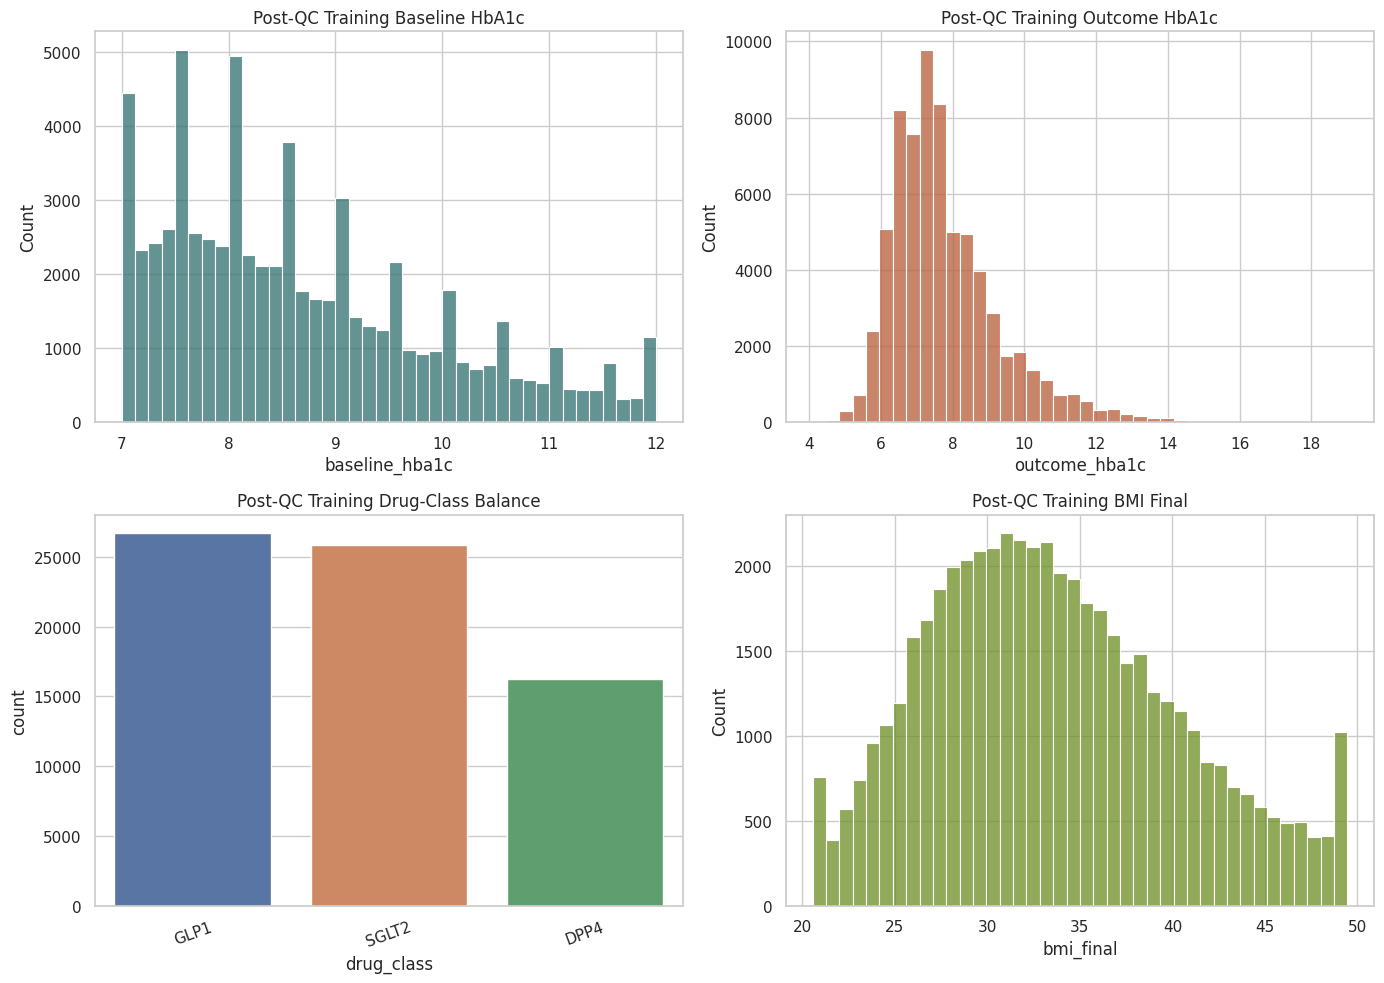

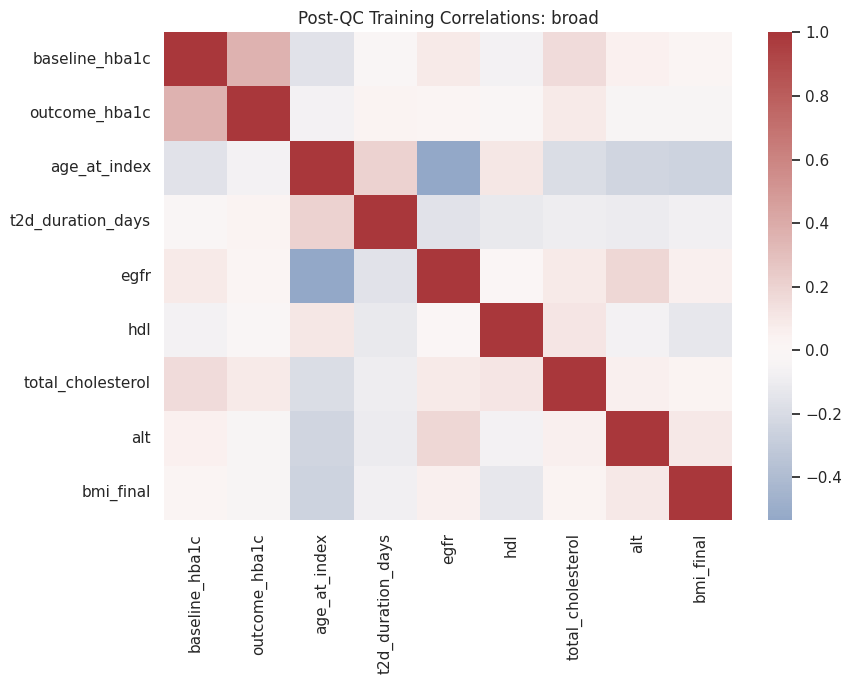

In [7]:
modeled_explore_df = mode_static_tables_modeling[EXPLORATION_OUTCOME_MODE].copy()
modeled_explore_train_df = modeled_explore_df[modeled_explore_df['split'] == 'train'].copy()

print('Post-QC exploration outcome mode:', EXPLORATION_OUTCOME_MODE)
print('Post-QC training rows:', len(modeled_explore_train_df))
print('Post-QC training patients:', modeled_explore_train_df['patient_id'].nunique())

post_qc_summary_rows = []
for mode, df in mode_static_tables_modeling.items():
    train_df = df[df['split'] == 'train'].copy()
    post_qc_summary_rows.append({
        'outcome_mode': mode,
        'train_rows_after_qc': len(train_df),
        'train_patients_after_qc': train_df['patient_id'].nunique(),
        'mean_outcome_hba1c': round(train_df['outcome_hba1c'].mean(), 3),
        'mean_baseline_hba1c': round(train_df['baseline_hba1c'].mean(), 3),
        'bmi_final_nonmissing_pct': round(train_df['bmi_final'].notna().mean() * 100, 2) if 'bmi_final' in train_df.columns else np.nan,
    })
display(pd.DataFrame(post_qc_summary_rows))

post_qc_numeric_features = [
    'age_at_index', 'baseline_hba1c', 't2d_duration_days', 'egfr', 'hdl',
    'total_cholesterol', 'alt', 'bmi_final', 'weight_lb', 'height_in',
    'glucose_med_record_rows_2y', 'first_glucose_med_days_before_index',
    'last_glucose_med_days_before_index', 'outcome_hba1c',
]
post_qc_numeric_features = [c for c in post_qc_numeric_features if c in modeled_explore_train_df.columns]

display(modeled_explore_train_df[post_qc_numeric_features].describe().T)

post_qc_missingness_table = pd.DataFrame({
    'feature': post_qc_numeric_features,
    'missing_rows_after_qc': [int(modeled_explore_train_df[c].isna().sum()) for c in post_qc_numeric_features],
    'missing_pct_after_qc': [round(modeled_explore_train_df[c].isna().mean() * 100, 2) for c in post_qc_numeric_features],
}).sort_values(['missing_pct_after_qc', 'feature'], ascending=[False, True])
display(post_qc_missingness_table)

post_qc_corr_features = [c for c in ['baseline_hba1c', 'outcome_hba1c', 'age_at_index', 't2d_duration_days', 'egfr', 'hdl', 'total_cholesterol', 'alt', 'bmi_final'] if c in modeled_explore_train_df.columns]
post_qc_corr = modeled_explore_train_df[post_qc_corr_features].corr(numeric_only=True)
display(post_qc_corr.round(3))

display(modeled_explore_train_df['drug_class'].value_counts(dropna=False).rename_axis('drug_class').to_frame('train_rows_after_qc'))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
sns.histplot(modeled_explore_train_df['baseline_hba1c'].dropna(), bins=40, ax=axes[0], color='#2f6f6f')
axes[0].set_title('Post-QC Training Baseline HbA1c')
sns.histplot(modeled_explore_train_df['outcome_hba1c'].dropna(), bins=40, ax=axes[1], color='#b85c38')
axes[1].set_title('Post-QC Training Outcome HbA1c')
sns.countplot(data=modeled_explore_train_df, x='drug_class', hue='drug_class', order=modeled_explore_train_df['drug_class'].value_counts().index, ax=axes[2], palette='deep', legend=False)
axes[2].set_title('Post-QC Training Drug-Class Balance')
axes[2].tick_params(axis='x', rotation=20)
if 'bmi_final' in modeled_explore_train_df.columns:
    sns.histplot(modeled_explore_train_df['bmi_final'].dropna(), bins=40, ax=axes[3], color='#6b8e23')
    axes[3].set_title('Post-QC Training BMI Final')
else:
    axes[3].set_visible(False)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(post_qc_corr, cmap='vlag', center=0, annot=False)
plt.title(f'Post-QC Training Correlations: {EXPLORATION_OUTCOME_MODE}')
plt.tight_layout()
plt.show()


## 7. Unsupervised Modeling With K-Means

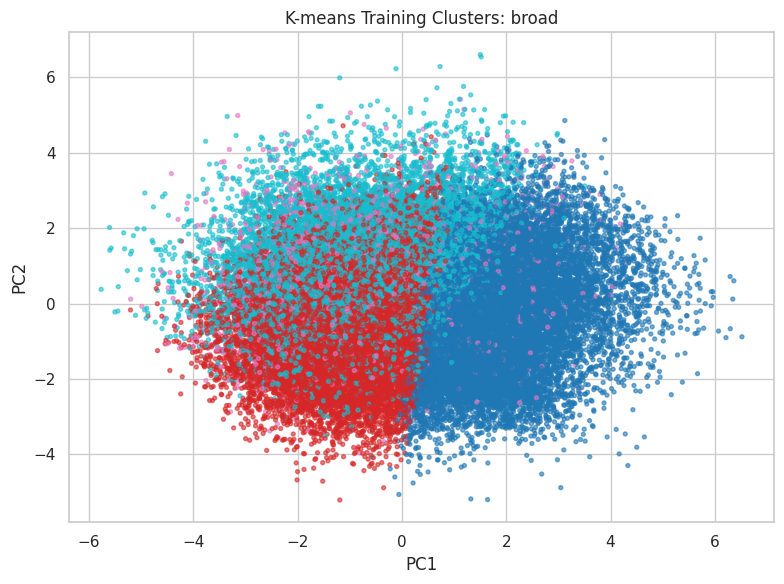

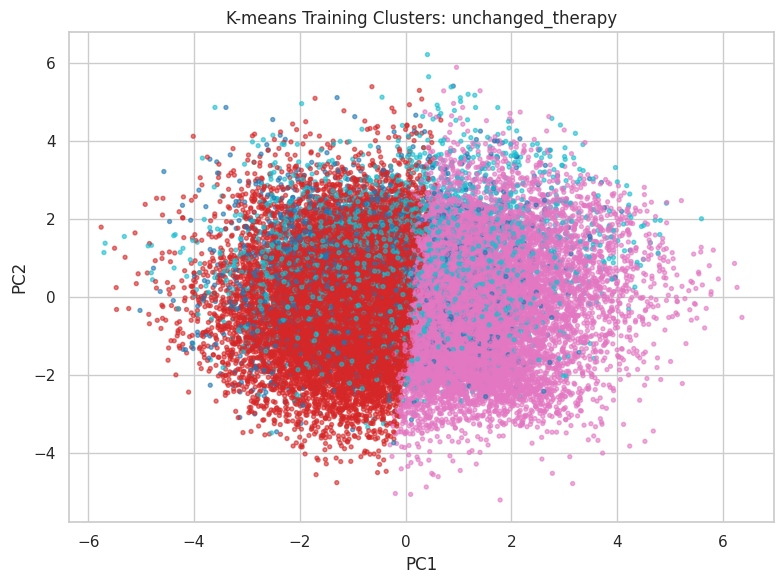

,outcome_mode,model_family,train_rows,validation_rows,test_rows,n_clusters,train_silhouette,inertia
0,broad,kmeans,68750,14375,14540,4,0.069891,1.230312e+06
1,unchanged_therapy,kmeans,35796,7626,7632,4,0.083815,6.374538e+05


,cluster,rows,mean_outcome_hba1c,outcome_mode,split
0,0,21618,7.776940,broad,train
1,1,28038,7.634025,broad,train
2,2,4341,8.018171,broad,train
3,3,14753,8.070626,broad,train
4,0,4458,7.773201,broad,validation
5,1,5952,7.623957,broad,validation
6,2,850,8.045471,broad,validation
7,3,3115,8.058109,broad,validation
8,0,4445,7.764803,broad,test
9,1,6070,7.612965,broad,test


In [8]:
if RUN_UNSUPERVISED:
    unsupervised_rows = []
    cluster_profiles = []
    for mode, df in mode_static_tables_modeling.items():
        train_df, val_df, test_df = get_split_frames(df)
        pre, X_train_t, y_train = fit_preprocessor_on_train(train_df)
        X_val_t, y_val = transform_with_preprocessor(pre, val_df)
        X_test_t, y_test = transform_with_preprocessor(pre, test_df)

        kmeans = KMeans(n_clusters=4, random_state=SEED, n_init=20)
        train_clusters = kmeans.fit_predict(X_train_t)
        val_clusters = kmeans.predict(X_val_t)
        test_clusters = kmeans.predict(X_test_t)

        unsupervised_rows.append({
            'outcome_mode': mode,
            'model_family': 'kmeans',
            'train_rows': len(train_df),
            'validation_rows': len(val_df),
            'test_rows': len(test_df),
            'n_clusters': 4,
            'train_silhouette': float(silhouette_score(X_train_t, train_clusters)) if len(np.unique(train_clusters)) > 1 else np.nan,
            'inertia': float(kmeans.inertia_),
        })

        for split_name, split_df, split_clusters in [
            ('train', train_df, train_clusters),
            ('validation', val_df, val_clusters),
            ('test', test_df, test_clusters),
        ]:
            tmp = split_df[['event_id', 'drug_class', 'outcome_hba1c']].copy()
            tmp['cluster'] = split_clusters
            prof = tmp.groupby('cluster').agg(
                rows=('event_id', 'count'),
                mean_outcome_hba1c=('outcome_hba1c', 'mean')
            ).reset_index()
            prof['outcome_mode'] = mode
            prof['split'] = split_name
            cluster_profiles.append(prof)

        pca = PCA(n_components=2, random_state=SEED)
        coords = pca.fit_transform(X_train_t)
        plt.figure(figsize=(8, 6))
        plt.scatter(coords[:, 0], coords[:, 1], c=train_clusters, s=8, cmap='tab10', alpha=0.6)
        plt.title(f'K-means Training Clusters: {mode}')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.tight_layout()
        plt.show()

    unsupervised_summary = pd.DataFrame(unsupervised_rows)
    unsupervised_profiles = pd.concat(cluster_profiles, ignore_index=True)
    unsupervised_summary.to_csv(UNSUPERVISED_RESULTS_PATH, index=False)
    unsupervised_profiles.to_csv(TRAINING_DIR / 'unsupervised_kmeans_profiles.csv', index=False)
    display(unsupervised_summary)
    display(unsupervised_profiles.head(20))
else:
    print('Set RUN_UNSUPERVISED = True to fit K-means on the training split and summarize cluster structure.')

## 8. Hyperparameter Tuning For The Two Non-Deep Learning Baselines

In [11]:
def make_static_model(model_family: str, params: dict | None = None):
    params = params or {}
    if model_family == 'elastic_net':
        model = ElasticNet(
            alpha=params.get('alpha', 0.01),
            l1_ratio=params.get('l1_ratio', 0.5),
            random_state=SEED,
            max_iter=5000,
        )
    elif model_family == 'hist_gradient_boosting':
        model = HistGradientBoostingRegressor(
            learning_rate=params.get('learning_rate', 0.05),
            max_depth=params.get('max_depth', 6),
            max_leaf_nodes=params.get('max_leaf_nodes', 31),
            min_samples_leaf=params.get('min_samples_leaf', 20),
            l2_regularization=params.get('l2_regularization', 0.0),
            random_state=SEED,
        )
    else:
        raise ValueError(model_family)
    return Pipeline([('preprocess', make_static_preprocessor()), ('model', model)])

if RUN_OPTUNA_STATIC:
    trial_rows = []
    best_params = {}
    sampler = optuna.samplers.TPESampler(seed=SEED)

    for mode, df in mode_static_tables_modeling.items():
        train_df, val_df, _ = get_split_frames(df)
        X_train, y_train = split_xy(train_df)
        X_val, y_val = split_xy(val_df)

        for model_family in ['elastic_net', 'hist_gradient_boosting']:
            def objective(trial):
                if model_family == 'elastic_net':
                    params = {
                        'alpha': trial.suggest_float('alpha', 1e-4, 1.0, log=True),
                        'l1_ratio': trial.suggest_float('l1_ratio', 0.05, 0.95),
                    }
                else:
                    params = {
                        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
                        'max_depth': trial.suggest_int('max_depth', 3, 10),
                        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63),
                        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
                        'l2_regularization': trial.suggest_float('l2_regularization', 1e-6, 1.0, log=True),
                    }
                model = make_static_model(model_family, params)
                model.fit(X_train, y_train)
                pred = model.predict(X_val)
                rmse = math.sqrt(mean_squared_error(y_val, pred))
                trial_rows.append({
                    'outcome_mode': mode,
                    'model_family': model_family,
                    'trial_number': trial.number,
                    'validation_rmse': float(rmse),
                    'params': json.dumps(params),
                })
                return rmse

            study = optuna.create_study(direction='minimize', sampler=sampler)
            study.optimize(objective, n_trials=N_TRIALS_STATIC, show_progress_bar=False)
            best_params.setdefault(mode, {})[model_family] = study.best_params

    pd.DataFrame(trial_rows).to_csv(STATIC_TUNING_PATH, index=False)
    STATIC_PARAM_PATH.write_text(json.dumps(best_params, indent=2))
    print(STATIC_TUNING_PATH)
    print(STATIC_PARAM_PATH)
    display(pd.read_csv(STATIC_TUNING_PATH).sort_values(['outcome_mode', 'model_family', 'validation_rmse']).groupby(['outcome_mode', 'model_family']).head(5))
else:
    print('Set RUN_OPTUNA_STATIC = True to tune Elastic Net and HistGradientBoosting with Optuna.')

[I 2026-04-02 13:39:23,219] A new study created in memory with name: no-name-5a27310c-832c-4dae-bef2-aa6e810559cc
[I 2026-04-02 13:39:23,517] Trial 0 finished with value: 1.3679644118911003 and parameters: {'alpha': 0.003148911647956862, 'l1_ratio': 0.9056428757689245}. Best is trial 0 with value: 1.3679644118911003.
[I 2026-04-02 13:39:23,797] Trial 1 finished with value: 1.3853471723576838 and parameters: {'alpha': 0.08471801418819976, 'l1_ratio': 0.588792635777333}. Best is trial 0 with value: 1.3679644118911003.
[I 2026-04-02 13:39:24,235] Trial 2 finished with value: 1.3678928693658803 and parameters: {'alpha': 0.00042079886696066364, 'l1_ratio': 0.19039506830258235}. Best is trial 2 with value: 1.3678928693658803.
[I 2026-04-02 13:39:24,597] Trial 3 finished with value: 1.3678913528704575 and parameters: {'alpha': 0.0001707396743152812, 'l1_ratio': 0.8295585311974416}. Best is trial 3 with value: 1.3678913528704575.
[I 2026-04-02 13:39:24,889] Trial 4 finished with value: 1.37136

/uufs/chpc.utah.edu/common/home/kukhareva-group1/Diabetes_Study/project_Andre/data/full_project/training/optuna_static_trials.csv
/uufs/chpc.utah.edu/common/home/kukhareva-group1/Diabetes_Study/project_Andre/data/full_project/training/optuna_static_best_params.json


,outcome_mode,model_family,trial_number,validation_rmse,params
11,broad,elastic_net,11,1.367889,"{""alpha"": 0.0016309745756684934, ""l1_ratio"": 0..."
10,broad,elastic_net,10,1.367889,"{""alpha"": 0.001759467864953183, ""l1_ratio"": 0...."
17,broad,elastic_net,17,1.367890,"{""alpha"": 0.0003683436877306918, ""l1_ratio"": 0..."
8,broad,elastic_net,8,1.367890,"{""alpha"": 0.0016480446427978971, ""l1_ratio"": 0..."
3,broad,elastic_net,3,1.367891,"{""alpha"": 0.0001707396743152812, ""l1_ratio"": 0..."
32,broad,hist_gradient_boosting,12,1.356911,"{""learning_rate"": 0.11318535246600066, ""max_de..."
21,broad,hist_gradient_boosting,1,1.356985,"{""learning_rate"": 0.10508421338691762, ""max_de..."
37,broad,hist_gradient_boosting,17,1.357269,"{""learning_rate"": 0.07760239168055857, ""max_de..."
27,broad,hist_gradient_boosting,7,1.357299,"{""learning_rate"": 0.15826541904647565, ""max_de..."
25,broad,hist_gradient_boosting,5,1.357615,"{""learning_rate"": 0.07277150634170934, ""max_de..."


## 9. Final Static Model Training And Test Evaluation

In [9]:
DEFAULT_STATIC_PARAMS = {
    'elastic_net': {'alpha': 0.01, 'l1_ratio': 0.5},
    'hist_gradient_boosting': {'learning_rate': 0.05, 'max_depth': 6, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'l2_regularization': 0.0},
}

if RUN_STATIC_FINAL:
    tuned = json.loads(STATIC_PARAM_PATH.read_text()) if STATIC_PARAM_PATH.exists() else {}
    results = []
    predictions = []
    for mode, df in mode_static_tables_modeling.items():
        train_df, val_df, test_df = get_split_frames(df)
        trainval_df = pd.concat([train_df, val_df], ignore_index=True)
        X_trainval, y_trainval = split_xy(trainval_df)
        X_test, y_test = split_xy(test_df)
        for model_family in ['elastic_net', 'hist_gradient_boosting']:
            params = tuned.get(mode, {}).get(model_family, DEFAULT_STATIC_PARAMS[model_family])
            model = make_static_model(model_family, params)
            model.fit(X_trainval, y_trainval)
            pred = model.predict(X_test)
            results.append({
                'outcome_mode': mode,
                'model_family': model_family,
                'split': 'test',
                'rows': len(test_df),
                **regression_metrics(y_test, pred),
                'params': json.dumps(params),
            })
            predictions.append(pd.DataFrame({
                'outcome_mode': mode,
                'model_family': model_family,
                'event_id': test_df['event_id'].values,
                'patient_id': test_df['patient_id'].astype('string').values,
                'y_true': y_test,
                'y_pred': pred,
            }))
    static_test_results = pd.DataFrame(results)
    static_test_results.to_csv(STATIC_TEST_RESULTS_PATH, index=False)
    pd.concat(predictions, ignore_index=True).to_csv(TRAINING_DIR / 'static_test_predictions.csv', index=False)
    display(static_test_results.sort_values(['outcome_mode', 'rmse']))
else:
    print('Set RUN_STATIC_FINAL = True to train the tuned static models on train+validation and evaluate on the test set.')

NameError: name 'make_static_model' is not defined

## 10. Build Chunkwise Sequence Caches For The Two Outcome Modes

In [9]:
SEQUENCE_CACHE_DIR = TRAINING_DIR / 'sequence_mode_caches'
SEQUENCE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def normalize_sequence_chunk(domain: str, chunk: pd.DataFrame) -> pd.DataFrame:
    chunk = chunk.copy()
    chunk['event_id'] = chunk['event_id'].astype('string')
    chunk['patient_id'] = chunk['patient_id'].astype('string')
    chunk['feature_name'] = chunk['feature_name'].astype('string')
    chunk['days_before_index'] = pd.to_numeric(chunk['days_before_index'], errors='coerce')
    if domain in {'sequence_hba1c', 'sequence_core_labs'}:
        chunk['value_numeric'] = pd.to_numeric(chunk['lab_result_num_val'], errors='coerce')
        chunk['feature_token'] = chunk['feature_name'].astype(str)
    elif domain == 'sequence_body_size':
        chunk['value_numeric'] = pd.to_numeric(chunk['value'], errors='coerce')
        chunk['feature_token'] = chunk['feature_name'].astype(str)
    elif domain == 'sequence_glucose_meds':
        code_str = chunk['code'].astype('string').fillna('missing_code') if 'code' in chunk.columns else pd.Series('missing_code', index=chunk.index, dtype='string')
        chunk['value_numeric'] = 1.0
        chunk['feature_token'] = 'med::' + code_str.astype(str)
    keep_cols = ['event_id', 'patient_id', 'days_before_index', 'feature_name', 'feature_token', 'value_numeric']
    chunk = chunk[keep_cols].dropna(subset=['event_id', 'days_before_index', 'feature_token'])
    return chunk

if RUN_SEQUENCE_CACHE_BUILD:
    for mode, df in mode_static_tables_modeling.items():
        event_ids = set(df['event_id'].astype('string').tolist())
        mode_dir = SEQUENCE_CACHE_DIR / mode
        mode_dir.mkdir(parents=True, exist_ok=True)
        vocab = set()
        summary_rows = []
        for domain in SEQUENCE_DOMAINS_FOR_GRU:
            src = aligned_sequence_paths[domain]
            out_path = mode_dir / f'{domain}__filtered.csv'
            wrote_header = False
            kept_rows = 0
            kept_events = set()
            if out_path.exists():
                out_path.unlink()
            for chunk in pd.read_csv(src, chunksize=SEQUENCE_CHUNKSIZE):
                chunk['event_id'] = chunk['event_id'].astype('string')
                chunk = chunk[chunk['event_id'].isin(event_ids)].copy()
                if chunk.empty:
                    continue
                chunk = normalize_sequence_chunk(domain, chunk)
                if chunk.empty:
                    continue
                chunk.to_csv(out_path, mode='a', header=not wrote_header, index=False)
                wrote_header = True
                kept_rows += len(chunk)
                kept_events.update(chunk['event_id'].unique().tolist())
                vocab.update(chunk['feature_token'].astype(str).unique().tolist())
            summary_rows.append({
                'outcome_mode': mode,
                'domain': domain,
                'rows': kept_rows,
                'events': len(kept_events),
                'path': str(out_path),
            })
        pd.DataFrame(summary_rows).to_csv(mode_dir / 'sequence_cache_summary.csv', index=False)
        pd.DataFrame({'feature_token': sorted(vocab)}).to_csv(mode_dir / 'sequence_feature_vocab.csv', index=False)
    print(SEQUENCE_CACHE_DIR)
else:
    print('Set RUN_SEQUENCE_CACHE_BUILD = True to build filtered sequence caches for the two outcome modes.')

/uufs/chpc.utah.edu/common/home/kukhareva-group1/Diabetes_Study/project_Andre/data/full_project/training/sequence_mode_caches


## 11. Deep Learning Helpers And Optuna Tuning

In [10]:
class StaticTensorDataset(Dataset):
    def __init__(self, X_num, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_num[idx], self.y[idx]


class SequenceDataset(Dataset):

    def __init__(self, token_ids, values, deltas, targets):

        self.token_ids = np.asarray(token_ids, dtype=np.int64)

        self.values = np.asarray(values, dtype=np.float32)

        self.deltas = np.asarray(deltas, dtype=np.float32)

        self.targets = np.asarray(targets, dtype=np.float32)

        self.lengths = np.maximum((self.token_ids != 0).sum(axis=1), 1).astype(np.int64)



    def __len__(self):

        return len(self.targets)



    def __getitem__(self, idx):

        return (

            torch.from_numpy(self.token_ids[idx]).long(),

            torch.from_numpy(self.values[idx]).float(),

            torch.from_numpy(self.deltas[idx]).float(),

            torch.tensor(self.lengths[idx], dtype=torch.long),

            torch.tensor(self.targets[idx], dtype=torch.float32),

        )





class StaticCNN(pl.LightningModule):
    def __init__(self, input_dim: int, channels: int = 32, dropout: float = 0.2, lr: float = LR, weight_decay: float = 1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.conv = nn.Sequential(
            nn.Conv1d(1, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(8),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels * 8, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )
        self.loss_fn = nn.SmoothL1Loss()

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        return self.head(x).squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log('train_loss', loss, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log('val_loss', loss, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)


class SequenceGRU(pl.LightningModule):

    def __init__(self, vocab_size: int, emb_dim: int = 32, hidden_dim: int = 64, dropout: float = 0.2, lr: float = LR, weight_decay: float = 1e-4, bidirectional: bool = GRU_BIDIRECTIONAL):

        super().__init__()

        self.save_hyperparameters()

        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)

        self.gru = nn.GRU(

            input_size=emb_dim + 2,

            hidden_size=hidden_dim,

            batch_first=True,

            bidirectional=bidirectional,

        )

        out_dim = hidden_dim * (2 if bidirectional else 1)

        self.head = nn.Sequential(

            nn.LayerNorm(out_dim),

            nn.Dropout(dropout),

            nn.Linear(out_dim, 1),

        )

        self.loss_fn = nn.SmoothL1Loss()



    def forward(self, token_ids, values, deltas, lengths):

        emb = self.embedding(token_ids)

        x = torch.cat([emb, values.unsqueeze(-1), (deltas / 730.0).unsqueeze(-1)], dim=-1)

        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)

        _, h = self.gru(packed)

        if self.hparams.bidirectional:

            features = torch.cat([h[-2], h[-1]], dim=-1)

        else:

            features = h[-1]

        return self.head(features).squeeze(-1)



    def training_step(self, batch, batch_idx):

        token_ids, values, deltas, lengths, y = batch

        pred = self(token_ids, values, deltas, lengths)

        loss = self.loss_fn(pred, y)

        self.log('train_loss', loss, prog_bar=False)

        return loss



    def validation_step(self, batch, batch_idx):

        token_ids, values, deltas, lengths, y = batch

        pred = self(token_ids, values, deltas, lengths)

        loss = self.loss_fn(pred, y)

        self.log('val_loss', loss, prog_bar=True)



    def configure_optimizers(self):

        return torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)





def build_dense_static_arrays(train_df, val_df, test_df):
    pre = make_static_preprocessor()
    X_train, y_train = split_xy(train_df)
    X_val, y_val = split_xy(val_df)
    X_test, y_test = split_xy(test_df)
    X_train_t = pre.fit_transform(X_train)
    X_val_t = pre.transform(X_val)
    X_test_t = pre.transform(X_test)
    if hasattr(X_train_t, 'toarray'):
        X_train_t = X_train_t.toarray()
        X_val_t = X_val_t.toarray()
        X_test_t = X_test_t.toarray()
    return pre, (X_train_t, y_train), (X_val_t, y_val), (X_test_t, y_test)


SEQUENCE_EXAMPLE_CACHE = {}


def sequence_example_cache_path(mode: str, split_name: str) -> Path:

    return SEQUENCE_EXAMPLE_CACHE_DIR / f'{mode}__{split_name}__seq{MAX_SEQ_LEN}.npz'



def load_or_build_sequence_examples(mode: str, split_name: str, force_rebuild: bool = False):

    key = (mode, split_name)

    if not force_rebuild and key in SEQUENCE_EXAMPLE_CACHE:

        return SEQUENCE_EXAMPLE_CACHE[key]



    cache_path = sequence_example_cache_path(mode, split_name)

    if cache_path.exists() and not force_rebuild:

        cached = np.load(cache_path, allow_pickle=False)

        bundle = {

            'token_ids': cached['token_ids'],

            'values': cached['values'],

            'deltas': cached['deltas'],

            'targets': cached['targets'],

            'vocab_size': int(cached['vocab_size'][0]),

        }

        SEQUENCE_EXAMPLE_CACHE[key] = bundle

        return bundle



    mode_dir = SEQUENCE_CACHE_DIR / mode

    vocab_path = mode_dir / 'sequence_feature_vocab.csv'

    if not vocab_path.exists():

        raise FileNotFoundError(f'Missing sequence cache vocab for mode={mode}. Run Section 10 first.')



    vocab = ['<PAD>'] + pd.read_csv(vocab_path)['feature_token'].astype(str).tolist()

    token_to_id = {tok: i for i, tok in enumerate(vocab)}

    split_events = set(mode_static_tables_modeling[mode].loc[mode_static_tables_modeling[mode]['split'] == split_name, 'event_id'].astype('string'))

    target_df = mode_static_tables_modeling[mode].loc[

        mode_static_tables_modeling[mode]['split'] == split_name,

        ['event_id', 'outcome_hba1c'],

    ].copy()



    bucket = defaultdict(list)

    for domain in SEQUENCE_DOMAINS_FOR_GRU:

        path = mode_dir / f'{domain}__filtered.csv'

        if not path.exists() or path.stat().st_size == 0:

            continue

        for chunk in pd.read_csv(path, chunksize=SEQUENCE_CHUNKSIZE):

            chunk['event_id'] = chunk['event_id'].astype('string')

            chunk = chunk[chunk['event_id'].isin(split_events)].copy()

            if chunk.empty:

                continue

            for row in chunk.itertuples(index=False):

                bucket[str(row.event_id)].append((float(row.days_before_index), token_to_id.get(str(row.feature_token), 0), float(row.value_numeric)))



    token_rows = []

    value_rows = []

    delta_rows = []

    targets = []



    for row in target_df.itertuples(index=False):

        seq = sorted(bucket.get(str(row.event_id), []), key=lambda x: x[0], reverse=True)

        if not seq:

            continue

        seq = seq[-MAX_SEQ_LEN:]

        pad = MAX_SEQ_LEN - len(seq)

        token_row = np.zeros(MAX_SEQ_LEN, dtype=np.int32)

        value_row = np.full(MAX_SEQ_LEN, SEQUENCE_VALUE_FILL, dtype=np.float32)

        delta_row = np.zeros(MAX_SEQ_LEN, dtype=np.float32)

        token_row[pad:] = np.array([x[1] for x in seq], dtype=np.int32)

        value_row[pad:] = np.array([x[2] for x in seq], dtype=np.float32)

        delta_row[pad:] = np.array([x[0] for x in seq], dtype=np.float32)

        token_rows.append(token_row)

        value_rows.append(value_row)

        delta_rows.append(delta_row)

        targets.append(float(row.outcome_hba1c))



    if token_rows:

        token_ids = np.stack(token_rows)

        values = np.stack(value_rows)

        deltas = np.stack(delta_rows)

        target_array = np.array(targets, dtype=np.float32)

    else:

        token_ids = np.zeros((0, MAX_SEQ_LEN), dtype=np.int32)

        values = np.zeros((0, MAX_SEQ_LEN), dtype=np.float32)

        deltas = np.zeros((0, MAX_SEQ_LEN), dtype=np.float32)

        target_array = np.zeros((0,), dtype=np.float32)



    bundle = {

        'token_ids': token_ids,

        'values': values,

        'deltas': deltas,

        'targets': target_array,

        'vocab_size': len(vocab),

    }



    np.savez_compressed(

        cache_path,

        token_ids=token_ids,

        values=values,

        deltas=deltas,

        targets=target_array,

        vocab_size=np.array([len(vocab)], dtype=np.int32),

    )

    SEQUENCE_EXAMPLE_CACHE[key] = bundle

    gc.collect()

    return bundle



@contextmanager
def temporarily_disable_slurm_env():
    removed = {}
    for key in list(os.environ):
        if key.startswith('SLURM_'):
            removed[key] = os.environ.pop(key)
    try:
        yield
    finally:
        os.environ.update(removed)


def make_loader(dataset, batch_size: int, shuffle: bool):
    worker_count = NUM_WORKERS if len(dataset) >= batch_size else 0
    kwargs = {
        'batch_size': batch_size,
        'shuffle': shuffle,
        'num_workers': worker_count,
        'pin_memory': PIN_MEMORY,
    }
    if worker_count > 0:
        kwargs['persistent_workers'] = True
    return DataLoader(dataset, **kwargs)


def fit_lightning_model(model, train_loader, val_loader, max_epochs):
    checkpoint_dir = TRAINING_DIR / 'lightning_checkpoints'
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_cb = ModelCheckpoint(
        dirpath=checkpoint_dir,
        filename='best-{epoch:02d}-{val_loss:.4f}',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
    )
    trainer_kwargs = {
        'max_epochs': max_epochs,
        'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu',
        'devices': 1,
        'logger': False,
        'enable_checkpointing': True,
        'enable_model_summary': False,
        'callbacks': [checkpoint_cb, EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, mode='min')],
        'gradient_clip_val': 1.0,
    }
    with temporarily_disable_slurm_env():
        trainer = pl.Trainer(**trainer_kwargs)
        trainer.fit(model, train_loader, val_loader)
    best_model = model
    if checkpoint_cb.best_model_path:
        best_model = type(model).load_from_checkpoint(checkpoint_cb.best_model_path)
        Path(checkpoint_cb.best_model_path).unlink(missing_ok=True)
    best_model.eval()
    return best_model, trainer


def predict_static_model(model, X, batch_size: int):
    dataset = StaticTensorDataset(X, np.zeros(len(X), dtype=np.float32))
    loader = make_loader(dataset, batch_size=batch_size, shuffle=False)
    device = model.device
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            preds.extend(model(xb.to(device)).cpu().numpy().tolist())
    return np.array(preds)


def predict_sequence_model(model, bundle, batch_size: int):

    dataset = SequenceDataset(bundle['token_ids'], bundle['values'], bundle['deltas'], bundle['targets'])

    loader = make_loader(dataset, batch_size=batch_size, shuffle=False)

    device = model.device

    preds = []

    with torch.no_grad():

        for token_ids, values, deltas, lengths, _ in loader:

            preds.extend(model(token_ids.to(device), values.to(device), deltas.to(device), lengths.to(device)).cpu().numpy().tolist())

    return np.array(preds)





def train_and_score_cnn(train_df, val_df, params):
    _, (X_train_t, y_train), (X_val_t, y_val), _ = build_dense_static_arrays(train_df, val_df, val_df)
    model = StaticCNN(
        input_dim=X_train_t.shape[1],
        channels=params['channels'],
        dropout=params['dropout'],
        lr=params['lr'],
    )
    model, _ = fit_lightning_model(
        model,
        make_loader(StaticTensorDataset(X_train_t, y_train), batch_size=params['batch_size'], shuffle=True),
        make_loader(StaticTensorDataset(X_val_t, y_val), batch_size=params['batch_size'], shuffle=False),
        CNN_MAX_EPOCHS,
    )
    pred = predict_static_model(model, X_val_t, batch_size=params['batch_size'])
    return model, math.sqrt(mean_squared_error(y_val, pred))


def train_and_score_gru(mode, params):

    train_bundle = load_or_build_sequence_examples(mode, 'train')

    val_bundle = load_or_build_sequence_examples(mode, 'validation')

    model = SequenceGRU(

        vocab_size=train_bundle['vocab_size'],

        emb_dim=params['emb_dim'],

        hidden_dim=params['hidden_dim'],

        dropout=params['dropout'],

        lr=params['lr'],

    )

    model, _ = fit_lightning_model(

        model,

        make_loader(SequenceDataset(train_bundle['token_ids'], train_bundle['values'], train_bundle['deltas'], train_bundle['targets']), batch_size=params['batch_size'], shuffle=True),

        make_loader(SequenceDataset(val_bundle['token_ids'], val_bundle['values'], val_bundle['deltas'], val_bundle['targets']), batch_size=params['batch_size'], shuffle=False),

        GRU_MAX_EPOCHS,

    )

    pred = predict_sequence_model(model, val_bundle, batch_size=params['batch_size'])

    rmse = math.sqrt(mean_squared_error(val_bundle['targets'], pred))

    gc.collect()

    if torch.cuda.is_available():

        torch.cuda.empty_cache()

    return model, rmse




def completed_trials(study):

    return [trial for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE and trial.value is not None]



def persist_deep_optuna_outputs(studies):

    trial_rows = []

    best_params = {}

    for (mode, model_family), study in studies.items():

        complete = completed_trials(study)

        for trial in complete:

            trial_rows.append({

                'outcome_mode': mode,

                'model_family': model_family,

                'trial_number': trial.number,

                'validation_rmse': float(trial.value),

                'params': json.dumps(trial.params),

            })

        if complete:

            best_params.setdefault(mode, {})[model_family] = study.best_params



    trial_df = pd.DataFrame(trial_rows)

    if not trial_df.empty:

        trial_df = trial_df.sort_values(['outcome_mode', 'model_family', 'trial_number']).reset_index(drop=True)

    trial_df.to_csv(DEEP_TUNING_PATH, index=False)

    DEEP_PARAM_PATH.write_text(json.dumps(best_params, indent=2))

    return trial_df, best_params



if RUN_OPTUNA_DEEP:

    DEEP_OPTUNA_STORAGE_PATH = globals().get('DEEP_OPTUNA_STORAGE_PATH', TRAINING_DIR / 'optuna_deep_studies.sqlite3')

    SEQUENCE_EXAMPLE_CACHE_DIR = globals().get('SEQUENCE_EXAMPLE_CACHE_DIR', TRAINING_DIR / 'sequence_example_cache')

    SEQUENCE_EXAMPLE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

    studies = {}

    sampler = optuna.samplers.TPESampler(seed=SEED)

    storage = f'sqlite:///{DEEP_OPTUNA_STORAGE_PATH}'



    for mode, df in mode_static_tables_modeling.items():

        train_df, val_df, _ = get_split_frames(df)



        def objective_cnn(trial):

            params = {

                'channels': trial.suggest_categorical('channels', [16, 32, 64]),

                'dropout': trial.suggest_float('dropout', 0.1, 0.5),

                'lr': trial.suggest_float('lr', 1e-4, 5e-3, log=True),

                'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512]),

            }

            _, rmse = train_and_score_cnn(train_df, val_df, params)

            gc.collect()

            if torch.cuda.is_available():

                torch.cuda.empty_cache()

            return rmse



        def objective_gru(trial):

            params = {

                'emb_dim': trial.suggest_categorical('emb_dim', [16, 32, 64]),

                'hidden_dim': trial.suggest_categorical('hidden_dim', [32, 64, 128]),

                'dropout': trial.suggest_float('dropout', 0.1, 0.5),

                'lr': trial.suggest_float('lr', 1e-4, 5e-3, log=True),

                'batch_size': trial.suggest_categorical('batch_size', [128, 256]),

            }

            _, rmse = train_and_score_gru(mode, params)

            gc.collect()

            if torch.cuda.is_available():

                torch.cuda.empty_cache()

            return rmse



        cnn_name = f'deep__{DEEP_STUDY_VERSION}__{mode}__cnn_static'

        study_cnn = optuna.create_study(

            direction='minimize',

            sampler=sampler,

            study_name=cnn_name,

            storage=storage,

            load_if_exists=True,

        )

        remaining_cnn = max(0, N_TRIALS_DEEP - len(completed_trials(study_cnn)))

        if remaining_cnn > 0:

            study_cnn.optimize(objective_cnn, n_trials=remaining_cnn, show_progress_bar=False, callbacks=[lambda study, trial: persist_deep_optuna_outputs(studies)])

        studies[(mode, 'cnn_static')] = study_cnn

        persist_deep_optuna_outputs(studies)



        gru_name = f'deep__{DEEP_STUDY_VERSION}__{mode}__gru_sequence'

        study_gru = optuna.create_study(

            direction='minimize',

            sampler=sampler,

            study_name=gru_name,

            storage=storage,

            load_if_exists=True,

        )

        remaining_gru = max(0, N_TRIALS_DEEP - len(completed_trials(study_gru)))

        if remaining_gru > 0:

            study_gru.optimize(objective_gru, n_trials=remaining_gru, show_progress_bar=False, callbacks=[lambda study, trial: persist_deep_optuna_outputs(studies)])

        studies[(mode, 'gru_sequence')] = study_gru

        persist_deep_optuna_outputs(studies)



    trial_df, best_params = persist_deep_optuna_outputs(studies)

    print(DEEP_TUNING_PATH)

    print(DEEP_PARAM_PATH)

    print(DEEP_OPTUNA_STORAGE_PATH)

    if not trial_df.empty:

        display(

            trial_df.sort_values(['outcome_mode', 'model_family', 'validation_rmse'])

            .groupby(['outcome_mode', 'model_family'])

            .head(5)

        )

else:

    print('Set RUN_OPTUNA_DEEP = True to tune the CNN and GRU with Optuna.')


[I 2026-04-03 22:31:01,771] A new study created in RDB with name: deep__seq128_gruuni_ep6__broad__cnn_static
  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()
[I 2026-04-03 22:32:02,902] Trial 0 finished with value: 1.4189207678020854 and parameters: {'channels': 32, 'dropout': 0.3394633936788146, 'lr': 0.00018410729205738696, 'batch_size': 512}. Best is trial 0 with value: 1.4189207678020854.
  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()
[I 2026-04-03 22:35:47,059] Trial 1 finished with value: 1.380599280796908 and parameters: {'channels': 32, 'dropout': 0.4879639408647978, 'lr': 0.002595942550311264, 'batch_size': 128}. Best is trial 1 with value: 1.380599280796908.
  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()
[I 2026-04-03 22:36:32,318] Trial 2 finished with value: 1.3979623580165332 and parameters: {'channels': 32, 'dropout': 0.21649165607921678, 'lr': 0.001095266274863256, 'batch_size': 512}. Best is trial 1 with value: 1.380599280796908.
  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()
[I 2026-04-03 22:38:09,997] Trial 3 finished with value: 1.3674550149799407 and parameters: {'channels': 32, 'dropout': 0.3056937753654446, 'lr': 0.0010150667045928574, 'batch_size': 256}. Best is trial 3 with value: 1.3674550149799407.
  raw_cnt = _raw_device_count_nvml()


...

  raw_cnt = _raw_device_count_nvml()
[I 2026-04-04 06:12:16,165] Trial 7 finished with value: 1.370712211396819 and parameters: {'emb_dim': 32, 'hidden_dim': 32, 'dropout': 0.44218423360440295, 'lr': 0.0015685327697616779, 'batch_size': 128}. Best is trial 6 with value: 1.32662063101119.
  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()
[I 2026-04-04 06:43:32,930] Trial 8 finished with value: 1.4298732215107148 and parameters: {'emb_dim': 16, 'hidden_dim': 128, 'dropout': 0.3540374603470575, 'lr': 0.00011939060520104558, 'batch_size': 256}. Best is trial 6 with value: 1.32662063101119.
  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()
[I 2026-04-04 07:08:24,278] Trial 9 finished with value: 1.3162188398387258 and parameters: {'emb_dim': 32, 'hidden_dim': 128, 'dropout': 0.11060452421664874, 'lr': 0.0009890429278092553, 'batch_size': 128}. Best is trial 9 with value: 1.3162188398387258.


/uufs/chpc.utah.edu/common/home/kukhareva-group1/Diabetes_Study/project_Andre/data/full_project/training/optuna_deep_trials.csv
/uufs/chpc.utah.edu/common/home/kukhareva-group1/Diabetes_Study/project_Andre/data/full_project/training/optuna_deep_best_params.json
/uufs/chpc.utah.edu/common/home/kukhareva-group1/Diabetes_Study/project_Andre/data/full_project/training/optuna_deep_studies.sqlite3


,outcome_mode,model_family,trial_number,validation_rmse,params
3,broad,cnn_static,3,1.367455,"{""channels"": 32, ""dropout"": 0.3056937753654446..."
1,broad,cnn_static,1,1.380599,"{""channels"": 32, ""dropout"": 0.4879639408647978..."
5,broad,cnn_static,5,1.384799,"{""channels"": 32, ""dropout"": 0.4637281608315128..."
6,broad,cnn_static,6,1.388568,"{""channels"": 64, ""dropout"": 0.4100531293444458..."
4,broad,cnn_static,4,1.389138,"{""channels"": 64, ""dropout"": 0.4233589392465845..."
12,broad,gru_sequence,2,1.416109,"{""emb_dim"": 32, ""hidden_dim"": 64, ""dropout"": 0..."
10,broad,gru_sequence,0,1.419190,"{""emb_dim"": 16, ""hidden_dim"": 128, ""dropout"": ..."
11,broad,gru_sequence,1,1.419952,"{""emb_dim"": 64, ""hidden_dim"": 64, ""dropout"": 0..."
17,broad,gru_sequence,7,1.426322,"{""emb_dim"": 16, ""hidden_dim"": 64, ""dropout"": 0..."
15,broad,gru_sequence,5,1.429576,"{""emb_dim"": 16, ""hidden_dim"": 64, ""dropout"": 0..."


## 12. Final CNN And GRU Training And Test Evaluation

In [12]:
DEFAULT_DEEP_PARAMS = {

    'cnn_static': {'channels': 32, 'dropout': 0.2, 'lr': LR, 'batch_size': BATCH_SIZE},

    'gru_sequence': {'emb_dim': 32, 'hidden_dim': 64, 'dropout': 0.2, 'lr': LR, 'batch_size': BATCH_SIZE},

}



if RUN_DEEP_FINAL:

    tuned = json.loads(DEEP_PARAM_PATH.read_text()) if DEEP_PARAM_PATH.exists() else {}

    deep_results = []

    for mode, df in mode_static_tables_modeling.items():

        train_df, val_df, test_df = get_split_frames(df)



        cnn_params = tuned.get(mode, {}).get('cnn_static', DEFAULT_DEEP_PARAMS['cnn_static'])

        _, (X_train_t, y_train), (X_val_t, y_val), (X_test_t, y_test) = build_dense_static_arrays(train_df, val_df, test_df)

        cnn = StaticCNN(

            input_dim=X_train_t.shape[1],

            channels=cnn_params['channels'],

            dropout=cnn_params['dropout'],

            lr=cnn_params['lr'],

        )

        cnn, _ = fit_lightning_model(

            cnn,

            make_loader(StaticTensorDataset(X_train_t, y_train), batch_size=cnn_params['batch_size'], shuffle=True),

            make_loader(StaticTensorDataset(X_val_t, y_val), batch_size=cnn_params['batch_size'], shuffle=False),

            CNN_MAX_EPOCHS,

        )

        cnn_pred = predict_static_model(cnn, X_test_t, batch_size=cnn_params['batch_size'])

        deep_results.append({

            'outcome_mode': mode,

            'model_family': 'cnn_static',

            'split': 'test',

            'rows': len(y_test),

            **regression_metrics(y_test, cnn_pred),

            'params': json.dumps(cnn_params),

        })



        gru_params = tuned.get(mode, {}).get('gru_sequence', DEFAULT_DEEP_PARAMS['gru_sequence'])

        train_bundle = load_or_build_sequence_examples(mode, 'train')

        val_bundle = load_or_build_sequence_examples(mode, 'validation')

        test_bundle = load_or_build_sequence_examples(mode, 'test')

        gru = SequenceGRU(

            vocab_size=train_bundle['vocab_size'],

            emb_dim=gru_params['emb_dim'],

            hidden_dim=gru_params['hidden_dim'],

            dropout=gru_params['dropout'],

            lr=gru_params['lr'],

        )

        gru, _ = fit_lightning_model(

            gru,

            make_loader(SequenceDataset(train_bundle['token_ids'], train_bundle['values'], train_bundle['deltas'], train_bundle['targets']), batch_size=gru_params['batch_size'], shuffle=True),

            make_loader(SequenceDataset(val_bundle['token_ids'], val_bundle['values'], val_bundle['deltas'], val_bundle['targets']), batch_size=gru_params['batch_size'], shuffle=False),

            GRU_MAX_EPOCHS,

        )

        preds = predict_sequence_model(gru, test_bundle, batch_size=gru_params['batch_size'])

        deep_results.append({

            'outcome_mode': mode,

            'model_family': 'gru_sequence',

            'split': 'test',

            'rows': len(test_bundle['targets']),

            **regression_metrics(test_bundle['targets'], preds),

            'params': json.dumps(gru_params),

        })



    deep_test_results = pd.DataFrame(deep_results)

    deep_test_results.to_csv(DEEP_TEST_RESULTS_PATH, index=False)

    display(deep_test_results.sort_values(['outcome_mode', 'rmse']))

else:

    print('Set RUN_DEEP_FINAL = True to train the tuned CNN and GRU with validation monitoring and evaluate on the test set.')


  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()


  raw_cnt = _raw_device_count_nvml()


,outcome_mode,model_family,split,rows,mae,rmse,r2,params
0,broad,cnn_static,test,14540,1.003153,1.403160,0.157348,"{""channels"": 32, ""dropout"": 0.3056937753654446..."
1,broad,gru_sequence,test,14493,1.037842,1.442210,0.106915,"{""emb_dim"": 32, ""hidden_dim"": 64, ""dropout"": 0..."
3,unchanged_therapy,gru_sequence,test,7620,0.973866,1.359477,0.126647,"{""emb_dim"": 32, ""hidden_dim"": 128, ""dropout"": ..."
2,unchanged_therapy,cnn_static,test,7632,0.979674,1.390114,0.088855,"{""channels"": 64, ""dropout"": 0.1948996349987200..."


## 13. Final Comparison And Manifest


,outcome_mode,model_family,split,rows,mae,rmse,r2,params
1,broad,hist_gradient_boosting,test,14540,1.013043,1.384640,0.179446,"{""learning_rate"": 0.11318535246600066, ""max_de..."
0,broad,elastic_net,test,14540,1.023873,1.397397,0.164256,"{""alpha"": 0.0016309745756684934, ""l1_ratio"": 0..."
4,broad,cnn_static,test,14540,1.003153,1.403160,0.157348,"{""channels"": 32, ""dropout"": 0.3056937753654446..."
5,broad,gru_sequence,test,14493,1.037842,1.442210,0.106915,"{""emb_dim"": 32, ""hidden_dim"": 64, ""dropout"": 0..."
3,unchanged_therapy,hist_gradient_boosting,test,7632,0.949658,1.308435,0.192783,"{""learning_rate"": 0.19957713696355242, ""max_de..."
2,unchanged_therapy,elastic_net,test,7632,0.961965,1.321264,0.176875,"{""alpha"": 0.009399668925324837, ""l1_ratio"": 0...."
7,unchanged_therapy,gru_sequence,test,7620,0.973866,1.359477,0.126647,"{""emb_dim"": 32, ""hidden_dim"": 128, ""dropout"": ..."
6,unchanged_therapy,cnn_static,test,7632,0.979674,1.390114,0.088855,"{""channels"": 64, ""dropout"": 0.1948996349987200..."


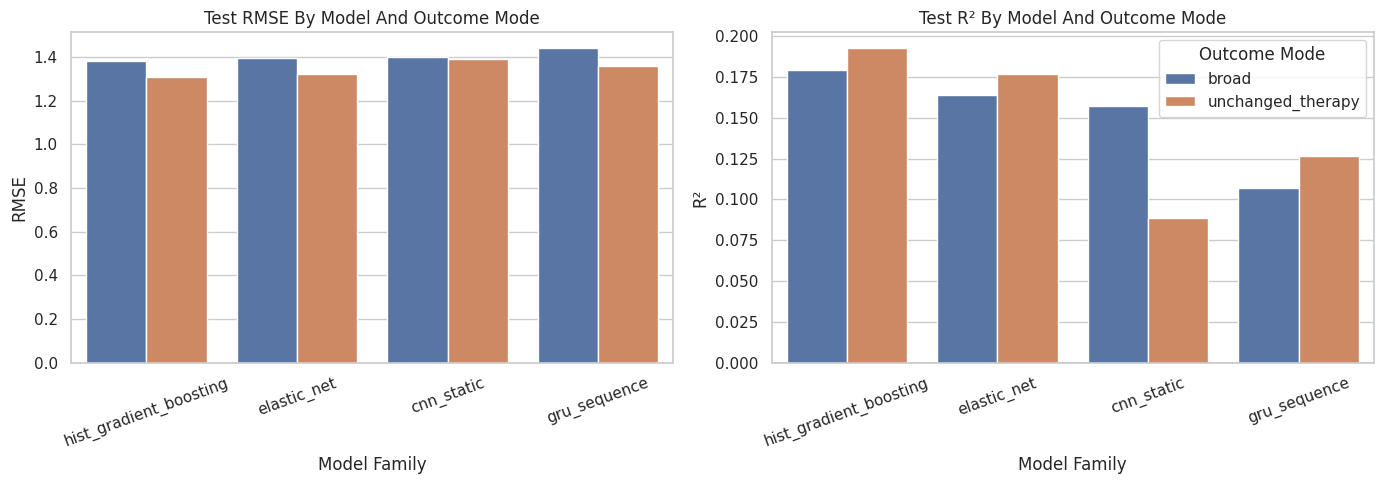

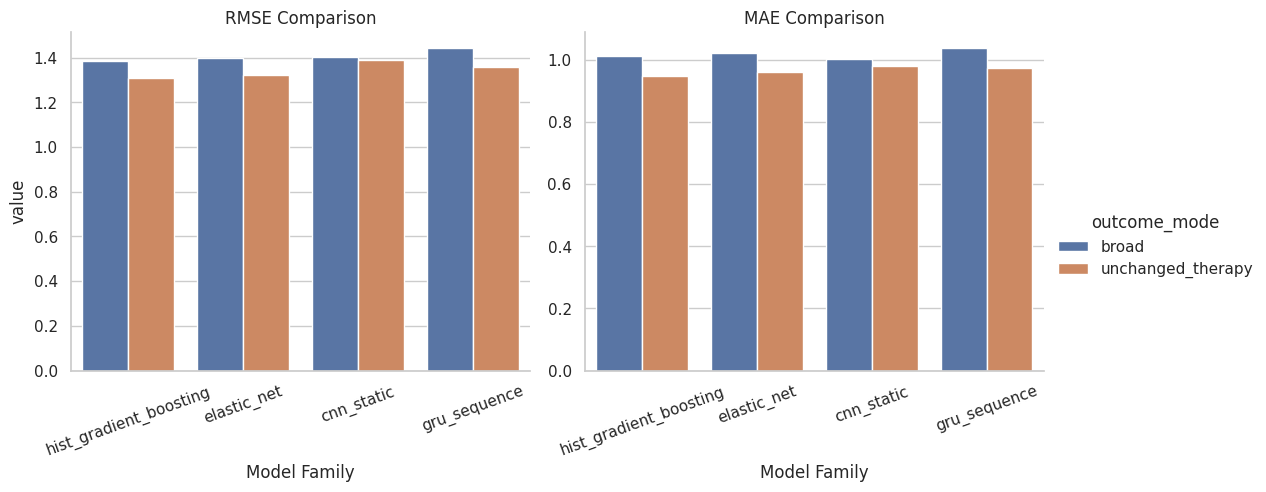

/uufs/chpc.utah.edu/common/home/kukhareva-group1/Diabetes_Study/project_Andre/data/full_project/training/training_manifest.json


In [13]:
comparison_frames = []
for path in [STATIC_TEST_RESULTS_PATH, DEEP_TEST_RESULTS_PATH]:
    if path.exists():
        comparison_frames.append(pd.read_csv(path))

if comparison_frames:
    model_comparison = pd.concat(comparison_frames, ignore_index=True)
    model_comparison = model_comparison.sort_values(['outcome_mode', 'rmse', 'mae'])
    model_comparison.to_csv(TRAINING_DIR / 'model_comparison.csv', index=False)
    display(model_comparison)

    plot_df = model_comparison.copy()
    model_order = plot_df.groupby('model_family')['rmse'].mean().sort_values().index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(
        data=plot_df,
        x='model_family',
        y='rmse',
        hue='outcome_mode',
        order=model_order,
        ax=axes[0],
        palette='deep',
    )
    axes[0].set_title('Test RMSE By Model And Outcome Mode')
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].set_xlabel('Model Family')
    axes[0].set_ylabel('RMSE')

    sns.barplot(
        data=plot_df,
        x='model_family',
        y='r2',
        hue='outcome_mode',
        order=model_order,
        ax=axes[1],
        palette='deep',
    )
    axes[1].axhline(0, color='black', linewidth=1, alpha=0.7)
    axes[1].set_title('Test R² By Model And Outcome Mode')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].set_xlabel('Model Family')
    axes[1].set_ylabel('R²')

    handles, labels = axes[1].get_legend_handles_labels()
    axes[0].legend_.remove()
    axes[1].legend(handles, labels, title='Outcome Mode')
    plt.tight_layout()
    plt.show()

    metric_plot_df = plot_df.melt(
        id_vars=['outcome_mode', 'model_family'],
        value_vars=['rmse', 'mae'],
        var_name='metric',
        value_name='value',
    )
    metric_plot_df['metric'] = metric_plot_df['metric'].str.upper()

    g = sns.catplot(
        data=metric_plot_df,
        x='model_family',
        y='value',
        hue='outcome_mode',
        col='metric',
        kind='bar',
        order=model_order,
        palette='deep',
        height=4.5,
        aspect=1.2,
        sharey=False,
    )
    g.set_titles('{col_name} Comparison')
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=20)
        ax.set_xlabel('Model Family')
    plt.show()
else:
    print('No final supervised test results written yet.')

training_manifest = {
    'outcome_modes': OUTCOME_MODES,
    'unsupervised_results': str(UNSUPERVISED_RESULTS_PATH) if UNSUPERVISED_RESULTS_PATH.exists() else None,
    'static_tuning_results': str(STATIC_TUNING_PATH) if STATIC_TUNING_PATH.exists() else None,
    'static_best_params': str(STATIC_PARAM_PATH) if STATIC_PARAM_PATH.exists() else None,
    'static_test_results': str(STATIC_TEST_RESULTS_PATH) if STATIC_TEST_RESULTS_PATH.exists() else None,
    'deep_tuning_results': str(DEEP_TUNING_PATH) if DEEP_TUNING_PATH.exists() else None,
    'deep_best_params': str(DEEP_PARAM_PATH) if DEEP_PARAM_PATH.exists() else None,
    'deep_test_results': str(DEEP_TEST_RESULTS_PATH) if DEEP_TEST_RESULTS_PATH.exists() else None,
    'comparison_table': str(TRAINING_DIR / 'model_comparison.csv') if (TRAINING_DIR / 'model_comparison.csv').exists() else None,
}
TRAINING_MANIFEST_PATH.write_text(json.dumps(training_manifest, indent=2))
print(TRAINING_MANIFEST_PATH)
